# DA-Fusion Local Pipeline

Local mirror of `kaggle_da_fusion_pipeline.ipynb`. Same DINOv2 ViT-S/14 backbone
and BiomassNet head as the competition baseline, but:

- paths resolve to this repo
- uses cached features from `src/cache/` when present, so the notebook re-runs in
  seconds
- runs three experiments back-to-back and prints a comparison table at the end:
  - **Baseline**: real images only
  - **RandAugment**: real images + classical pixel-space augmentation extracted
    through DINOv2
  - **DA-Fusion**:real + Stable-Diffusion synthetic images (from
    `generate_augmented.py`), leakage-filtered against the val split

This notebook is what produces prints some of the data images shown in the report, and the final validation metrics table. The Kaggle pipeline is identical except for paths and the fact that it only runs the DA-Fusion experiment (to save time).


## Setup & Imports

In [ ]:
import os, math, random
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
print(f"Torch  : {torch.__version__}")


Device : cpu
Torch  : 2.5.1


## Configuration

All paths are local. `cfg.dino_weights_dir` points at the repo-level
`dinov2-small/` folder (same HuggingFace snapshot used on Kaggle).


In [ ]:
REPO_ROOT = Path(r"C:\Users\Eier\OneDrive\Maskinlæring\INF367A\CSIRO---Image2Biomass-Prediction")

cfg = SimpleNamespace(
    # --- Paths (all local) ---
    csv_path          = REPO_ROOT / "data" / "tabular" / "train" / "train.csv",
    aug_csv           = REPO_ROOT / "data" / "tabular" / "train" / "train_augmented.csv",
    train_img_dir     = REPO_ROOT / "data" / "image" / "train",
    image_dir         = REPO_ROOT / "data" / "image",
    dino_weights_dir  = REPO_ROOT / "dinov2-small",
    cache_dir         = REPO_ROOT / "src" / "cache",
    # --- Model (matches baseline) ---
    input_dim   = 384,
    latent_dim  = 64,
    output_dim  = 5,
    dropout     = 0.1,
    # --- Training ---
    epochs       = 80,
    batch_size   = 32,
    lr           = 3e-4,
    weight_decay = 1e-3,
    seed         = SEED,
    # --- Split ---
    n_splits = 5,
    val_fold = 0,
    # --- RandAugment passes (how many augmented copies of each real train image) ---
    randaug_passes = 3,
)
cfg.cache_dir.mkdir(parents=True, exist_ok=True)

TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
           "GDM_g": 0.2, "Dry_Total_g": 0.5}

print("train.csv      :", cfg.csv_path.exists())
print("train img dir  :", cfg.train_img_dir.exists())
print("aug csv        :", cfg.aug_csv.exists())
print("dino weights   :", cfg.dino_weights_dir.exists())
print("cache dir      :", cfg.cache_dir.exists())


## Load Training CSV

In [3]:
df_raw = pd.read_csv(cfg.csv_path)
df_raw["image_id"] = df_raw["sample_id"].str.split("__").str[0]

train_df = df_raw.pivot_table(
    index=["image_id", "image_path"],
    columns="target_name",
    values="target",
).reset_index()

Y_all_real          = train_df[TARGETS].values.astype(np.float32)
train_image_ids_all = train_df["image_id"].values

print(f"Training images: {len(train_df)}")
print(f"Y shape: {Y_all_real.shape}")
train_df.head(3)


Training images: 357
Y shape: (357, 5)


target_name,image_id,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,ID1011485656,train/ID1011485656.jpg,0.00,31.9984,16.2751,48.2735,16.275
1,ID1012260530,train/ID1012260530.jpg,0.00,0.0000,7.6000,7.6000,7.600
2,ID1025234388,train/ID1025234388.jpg,6.05,0.0000,0.0000,6.0500,6.050


## 4. Data Exploration — Targets

Per-target descriptive stats, weighted mass fraction (how much each target
contributes to the competition metric), and the target-target correlation
matrix. Numbers below go directly into the report.


In [4]:
stats = train_df[TARGETS].describe().T[["count", "mean", "std", "min", "50%", "max"]]
stats.columns = ["N", "mean", "std", "min", "median", "max"]
print("Per-target stats (grams):")
print(stats.round(2).to_string())

total_w = (train_df[TARGETS].abs().sum(axis=0) * pd.Series(WEIGHTS)).sum()
contrib = {t: float((train_df[t].abs().sum() * WEIGHTS[t]) / total_w) for t in TARGETS}
print("\nCompetition-weight mass fraction per target (sums to 1):")
for t, f in contrib.items():
    print(f"  {t:<14}: {f:.3f}")

print("\nPearson correlation between targets:")
print(train_df[TARGETS].corr().round(2).to_string())


Per-target stats (grams):
                  N   mean    std   min  median     max
target_name                                            
Dry_Green_g   357.0  26.62  25.40  0.00   20.80  157.98
Dry_Dead_g    357.0  12.04  12.40  0.00    7.98   83.84
Dry_Clover_g  357.0   6.65  12.12  0.00    1.42   71.79
GDM_g         357.0  33.27  24.94  1.04   27.11  157.98
Dry_Total_g   357.0  45.32  27.98  1.04   40.30  185.70

Competition-weight mass fraction per target (sums to 1):
  Dry_Green_g   : 0.079
  Dry_Dead_g    : 0.036
  Dry_Clover_g  : 0.020
  GDM_g         : 0.197
  Dry_Total_g   : 0.669

Pearson correlation between targets:
target_name   Dry_Green_g  Dry_Dead_g  Dry_Clover_g  GDM_g  Dry_Total_g
target_name                                                            
Dry_Green_g          1.00        0.10         -0.28   0.88         0.83
Dry_Dead_g           0.10        1.00         -0.18   0.01         0.45
Dry_Clover_g        -0.28       -0.18          1.00   0.20         0.10
GDM_g 

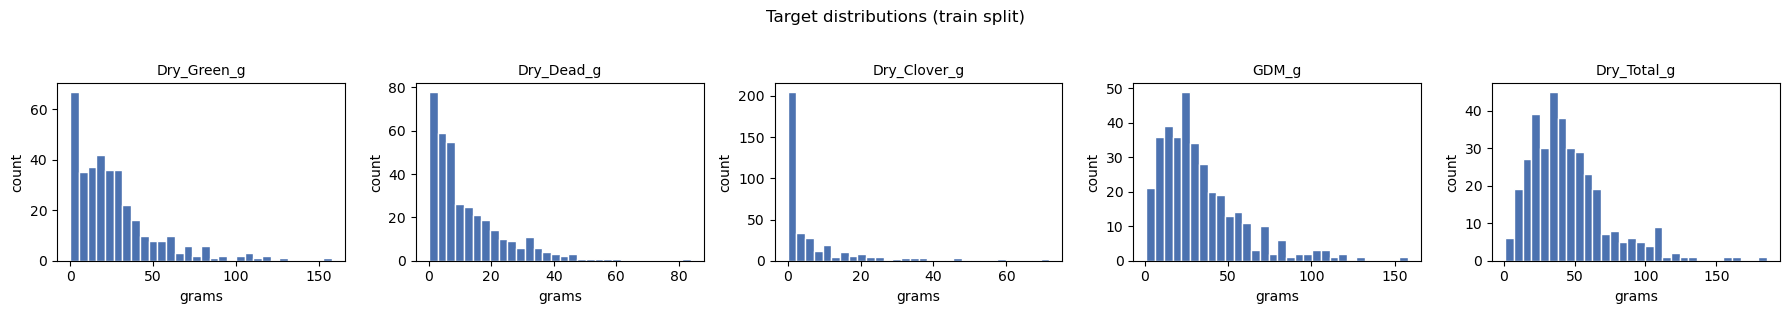

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, t in zip(axes, TARGETS):
    ax.hist(train_df[t].values, bins=30, color="#4c72b0", edgecolor="white")
    ax.set_title(t, fontsize=10)
    ax.set_xlabel("grams"); ax.set_ylabel("count")
fig.suptitle("Target distributions (train split)", y=1.03, fontsize=12)
plt.tight_layout(); plt.show()


## Data Exploration: Sample Images

Six real training images sampled across the `Dry_Total_g` range, plus one
DA-Fusion synthetic per learned token if `train_augmented.csv` is present.
These figures illustrate what DINOv2 consumes.


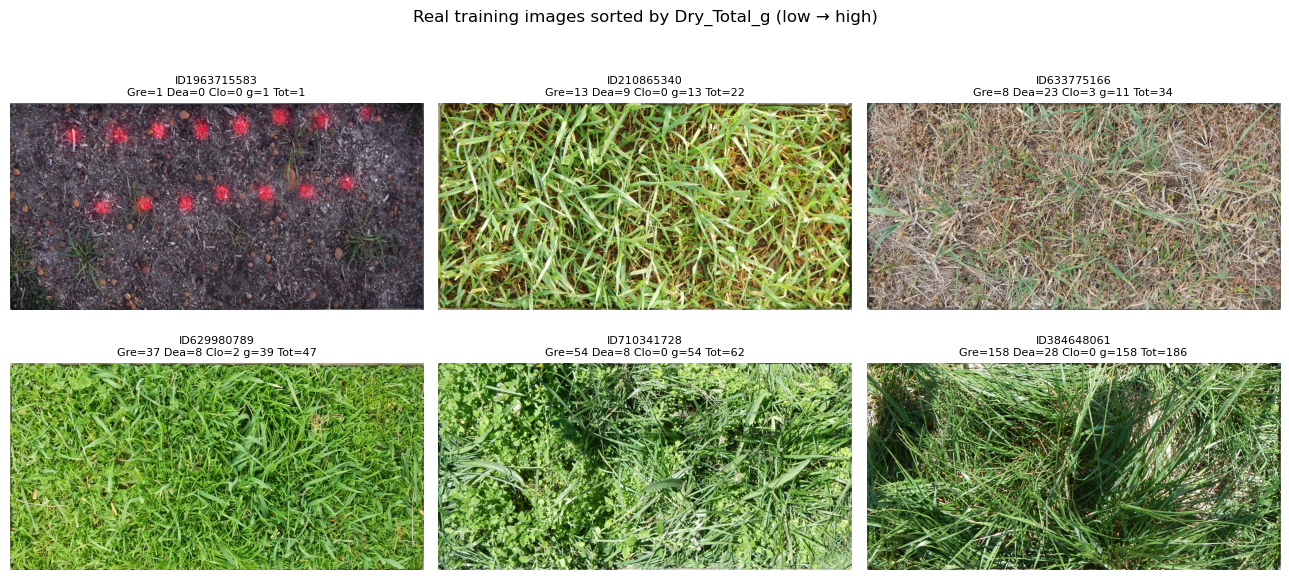

Real-image sizes in first 20 samples: {(2000, 1000)}


In [6]:
sorted_df  = train_df.sort_values("Dry_Total_g").reset_index(drop=True)
picks      = [0, len(sorted_df)//5, 2*len(sorted_df)//5,
              3*len(sorted_df)//5, 4*len(sorted_df)//5, len(sorted_df)-1]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, idx in zip(axes.flat, picks):
    row = sorted_df.iloc[idx]
    img_path = cfg.train_img_dir / f"{row['image_id']}.jpg"
    if img_path.exists():
        im = Image.open(img_path).convert("RGB")
        ax.imshow(im)
        title = f"{row['image_id']}\n" + " ".join(
            f"{t.split('_')[1][:3]}={row[t]:.0f}" for t in TARGETS
        )
        ax.set_title(title, fontsize=8)
    ax.axis("off")
fig.suptitle("Real training images sorted by Dry_Total_g (low → high)", y=1.02)
plt.tight_layout(); plt.show()

_sizes = []
for iid in train_df["image_id"].head(20):
    p = cfg.train_img_dir / f"{iid}.jpg"
    if p.exists():
        _sizes.append(Image.open(p).size)
print(f"Real-image sizes in first 20 samples: {set(_sizes)}")


Synthetic rows in CSV: 1071


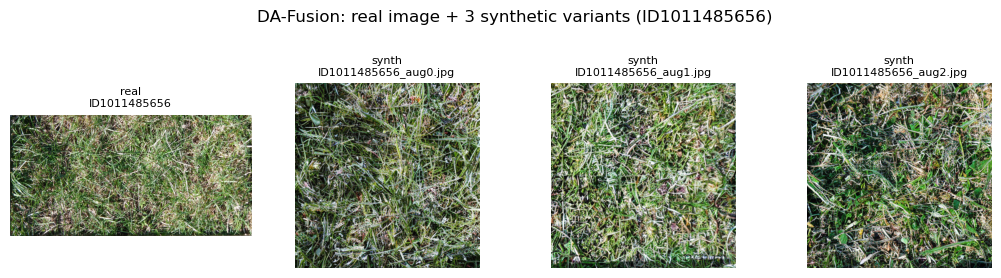

Synthetics per source image - mean=3.00, min=3, max=3, n_sources=357


In [18]:
if cfg.aug_csv.exists():
    _df_aug   = pd.read_csv(cfg.aug_csv)
    _df_synth = _df_aug[_df_aug["is_synthetic"].astype(bool)].reset_index(drop=True)
    print(f"Synthetic rows in CSV: {len(_df_synth)}")

    _df_synth["source_id"] = _df_synth["source_image"].apply(
        lambda p: Path(str(p)).stem
    )

    # Pick the first source image that actually has synthetics on disk
    _chosen_src = None
    for sid, grp in _df_synth.groupby("source_id"):
        real_p = cfg.train_img_dir / f"{sid}.jpg"
        synth_ps = [cfg.image_dir / r["image_path"] for _, r in grp.iterrows()]
        if real_p.exists() and all(p.exists() for p in synth_ps):
            _chosen_src = (sid, real_p, synth_ps[:3])  # cap at 3 synthetics
            break

    if _chosen_src is None:
        print("[skip] no source image with all synthetic files on disk.")
    else:
        sid, real_p, synth_ps = _chosen_src
        n = 1 + len(synth_ps)
        fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.6))
        axes[0].imshow(Image.open(real_p).convert("RGB"))
        axes[0].set_title(f"real\n{sid}", fontsize=8)
        axes[0].axis("off")
        for ax, sp in zip(axes[1:], synth_ps):
            ax.imshow(Image.open(sp).convert("RGB"))
            ax.set_title(f"synth\n{sp.name}", fontsize=8)
            ax.axis("off")
        fig.suptitle(f"DA-Fusion: real image + 3 synthetic variants ({sid})", y=1.05)
        plt.tight_layout(); plt.show()

    _per_source = _df_synth["source_id"].value_counts()
    print(f"Synthetics per source image - mean={_per_source.mean():.2f}, "
          f"min={_per_source.min()}, max={_per_source.max()}, "
          f"n_sources={len(_per_source)}")
else:
    print("[skip] train_augmented.csv not found. Run generate_augmented.py first.")

## Load DINOv2 ViT-S/14

Same backbone as `kaggle_da_fusion_pipeline.ipynb`. Weights are the cached
HuggingFace snapshot in `dinov2-small/`. Frozen - only the BiomassNet head on
top is trained.


In [ ]:
# Try local snapshot first (any folder containing config.json + weights);
# if none is found, fall back to the public HuggingFace checkpoint.
_LOCAL_DINO_CANDIDATES = [
    cfg.dino_weights_dir,
    REPO_ROOT / "dinov2-small",
    REPO_ROOT / ".claude" / "worktrees" / "nervous-engelbart" / "dinov2-small",
    Path.cwd() / "dinov2-small",
]

def _has_dino_weights(p: Path) -> bool:
    if not p.is_dir():
        return False
    has_cfg = (p / "config.json").exists()
    has_w   = any((p / n).exists() for n in
                  ("model.safetensors", "pytorch_model.bin"))
    return has_cfg and has_w

_resolved = next((p for p in _LOCAL_DINO_CANDIDATES if _has_dino_weights(p)), None)
if _resolved is not None:
    print(f"Loading DINOv2 ViT-S/14 from local snapshot: {_resolved}")
    dino = AutoModel.from_pretrained(str(_resolved)).eval().to(device)
else:
    print("No local DINOv2 snapshot found - downloading facebook/dinov2-small ...")
    dino = AutoModel.from_pretrained("facebook/dinov2-small").eval().to(device)

for p in dino.parameters():
    p.requires_grad_(False)

_dummy = torch.zeros(1, 3, 252, 504, device=device)
with torch.no_grad():
    _out = dino(pixel_values=_dummy, interpolate_pos_encoding=True)
    _cls = _out.last_hidden_state[:, 0, :]
assert _cls.shape == (1, 384), f"Expected (1, 384), got {_cls.shape}"
print(f"DINOv2 smoke test passed - CLS shape: {_cls.shape}")
del _dummy, _out, _cls


Loading DINOv2 ViT-S/14 from local snapshot: C:\Users\Eier\OneDrive\Maskinlæring\INF367A\CSIRO---Image2Biomass-Prediction\.claude\worktrees\nervous-engelbart\dinov2-small
DINOv2 smoke test passed - CLS shape: torch.Size([1, 384])


## Extract DINOv2 Features - Real Images

Cached to `src/cache/features_dinov2.npy`. Extraction uses DINOv2's native
504×252 input.


In [ ]:
_dino_transform = T.Compose([
    T.Resize((252, 504)),                 # (H, W)
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_features(image_paths, model, transform):
    feats = []
    for i, p in enumerate(image_paths):
        img = Image.open(p).convert("RGB")
        x   = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out  = model(pixel_values=x, interpolate_pos_encoding=True)
            feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
        feats.append(feat)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(image_paths)}")
    return np.stack(feats).astype(np.float32)


REAL_FEATS_CACHE = cfg.cache_dir / "features_dinov2.npy"
REAL_IDS_CACHE   = cfg.cache_dir / "image_ids.npy"

if REAL_FEATS_CACHE.exists() and REAL_IDS_CACHE.exists():
    X_real       = np.load(REAL_FEATS_CACHE).astype(np.float32)
    real_ids_np  = np.load(REAL_IDS_CACHE, allow_pickle=True)
    print(f"Loaded cached real features: {X_real.shape}")
else:
    paths = [str(cfg.train_img_dir / f"{iid}.jpg") for iid in train_image_ids_all]
    X_real      = extract_features(paths, dino, _dino_transform)
    real_ids_np = np.asarray(train_image_ids_all)
    np.save(REAL_FEATS_CACHE, X_real)
    np.save(REAL_IDS_CACHE,   real_ids_np)
    print(f"Saved real feature cache: {X_real.shape}")

# align labels to cached feature order
id_to_label = {row.image_id: row[list(TARGETS)].values
               for _, row in train_df.iterrows()}
# pandas .values on a Series returns float list - stack to (N,5)
_label_rows = []
for iid in real_ids_np:
    sub = train_df[train_df["image_id"] == iid][TARGETS].values
    _label_rows.append(sub[0] if len(sub) else np.zeros(5, dtype=np.float32))
Y_real = np.asarray(_label_rows, dtype=np.float32)
print(f"Y_real: {Y_real.shape}")


Loaded cached real features: (357, 384)
Y_real: (357, 5)


## GroupKFold Split (fold 0)


In [10]:
gkf = GroupKFold(n_splits=cfg.n_splits)
splits = list(gkf.split(X_real, groups=np.arange(len(X_real))))
train_idx, val_idx = splits[cfg.val_fold]

train_source_ids = set(real_ids_np[train_idx].tolist())
val_source_ids   = set(real_ids_np[val_idx].tolist())
assert train_source_ids.isdisjoint(val_source_ids), "Group leakage!"

X_tr_real = X_real[train_idx]
Y_tr_real = Y_real[train_idx]
X_val     = X_real[val_idx]
Y_val     = Y_real[val_idx]

print(f"Train rows (real): {len(train_idx)}")
print(f"Val   rows (real): {len(val_idx)}")


Train rows (real): 285
Val   rows (real): 72


## BiomassNet, Loss, Training Loop

Identical architecture and loss to `kaggle_da_fusion_pipeline.ipynb` - 384->256->64
encoder, 64->32->5 head, weighted SmoothL1. Wrapped in `run_experiment(...)` so the
three experiments below share the exact same optimizer/schedule/epoch budget.


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim=384, latent_dim=64, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
        )
    def forward(self, x): return self.net(x)


class Head(nn.Module):
    def __init__(self, latent_dim=64, output_dim=5, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(32, output_dim),
        )
    def forward(self, z): return self.net(z)


class BiomassModel(nn.Module):
    def __init__(self, input_dim=384, latent_dim=64, output_dim=5, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim, dropout)
        self.head    = Head(latent_dim, output_dim, dropout)
    def forward(self, x): return self.head(self.encoder(x))


_WV = np.array([WEIGHTS[t] for t in TARGETS], dtype=np.float64)
_LOSS_W = torch.tensor(_WV, dtype=torch.float32)


def _weighted_smooth_l1(pred, target, weights, beta=1.0):
    loss_per = nn.functional.smooth_l1_loss(pred, target, beta=beta, reduction="none")
    return (loss_per * weights.to(pred.device)).mean()


def weighted_global_r2(y_true, y_pred):
    yt = y_true.reshape(-1); yp = y_pred.reshape(-1)
    ww = np.repeat(_WV, y_true.shape[0])
    ybar = np.sum(ww * yt) / np.sum(ww)
    ss_res = np.sum(ww * (yt - yp) ** 2)
    ss_tot = np.sum(ww * (yt - ybar) ** 2) + 1e-12
    return float(1.0 - ss_res / ss_tot)


def rmse_per_target(y_true, y_pred):
    return {t: float(np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])))
            for i, t in enumerate(TARGETS)}


class _DS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


def run_experiment(name, X_train, Y_train, X_val, Y_val, *, epochs=None, verbose=True):
    """Train BiomassNet; return (best_val_r2, best_rmse_dict, history)."""
    epochs = epochs or cfg.epochs
    torch.manual_seed(cfg.seed); np.random.seed(cfg.seed); random.seed(cfg.seed)

    train_loader = DataLoader(_DS(X_train, Y_train), batch_size=cfg.batch_size, shuffle=True)
    val_loader   = DataLoader(_DS(X_val,   Y_val),   batch_size=64,              shuffle=False)

    model     = BiomassModel(cfg.input_dim, cfg.latent_dim, cfg.output_dim, cfg.dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=cfg.lr / 100)

    best_r2, best_rmse, best_state = -float("inf"), None, None
    hist = {"train_loss": [], "val_r2": []}
    for ep in range(1, epochs + 1):
        model.train()
        ep_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = _weighted_smooth_l1(model(X), y, _LOSS_W)
            loss.backward(); optimizer.step()
            ep_loss += loss.item() * len(X)
        scheduler.step()
        tr = ep_loss / len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            yp = []
            for X, _ in val_loader:
                yp.append(model(X.to(device)).cpu().numpy())
            yp = np.concatenate(yp)
        r2   = weighted_global_r2(Y_val, yp)
        rmse = rmse_per_target(Y_val, yp)
        hist["train_loss"].append(tr); hist["val_r2"].append(r2)

        if r2 > best_r2:
            best_r2, best_rmse = r2, rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if verbose and (ep == 1 or ep % 10 == 0 or ep == epochs):
            print(f"  [{name}] ep {ep:3d}  tr={tr:.4f}  val_R²={r2:.4f}")

    best_ep = int(np.argmax(hist["val_r2"])) + 1
    print(f"  [{name}] best val R² = {best_r2:.4f} at epoch {best_ep}")
    return best_r2, best_rmse, hist


## Experiment 1 - Baseline (real images only)

Real DINOv2 features from the train fold; validate on the val fold. No
augmentation of any kind.


In [12]:
print("=== EXPERIMENT 1: Baseline (real data only) ===")
print(f"Train: {X_tr_real.shape}  Val: {X_val.shape}")

r2_1, rmse_1, hist_1 = run_experiment("Baseline",
                                      X_tr_real, Y_tr_real,
                                      X_val,      Y_val)
print(f"\nBaseline weighted R² (best) = {r2_1:.4f}")
for t in TARGETS:
    print(f"  RMSE {t:<18}: {rmse_1[t]:.4f}")


=== EXPERIMENT 1: Baseline (real data only) ===
Train: (285, 384)  Val: (72, 384)
  [Baseline] ep   1  tr=6.5511  val_R²=-1.0607
  [Baseline] ep  10  tr=3.1774  val_R²=0.2704
  [Baseline] ep  20  tr=2.3418  val_R²=0.5681
  [Baseline] ep  30  tr=2.0689  val_R²=0.6099
  [Baseline] ep  40  tr=1.9631  val_R²=0.6410
  [Baseline] ep  50  tr=1.9229  val_R²=0.6638
  [Baseline] ep  60  tr=1.8694  val_R²=0.6712
  [Baseline] ep  70  tr=1.8126  val_R²=0.6805
  [Baseline] ep  80  tr=1.7809  val_R²=0.6765
  [Baseline] best val R² = 0.6805 at epoch 70

Baseline weighted R² (best) = 0.6805
  RMSE Dry_Green_g       : 16.1058
  RMSE Dry_Dead_g        : 11.1886
  RMSE Dry_Clover_g      : 13.6111
  RMSE GDM_g             : 13.8854
  RMSE Dry_Total_g       : 14.5516


## Experiment 2 - RandAugment

Re-extract DINOv2 features from each real **train** image `cfg.randaug_passes`
times with `RandAugment(num_ops=2, magnitude=9)` applied before the DINOv2
transform. The augmented rows are appended to the real train rows. Validation
features stay clean. Cached to `src/cache/features_dinov2_randaug.npy`.


In [13]:
RA_FEATS_CACHE = cfg.cache_dir / f"features_dinov2_randaug_p{cfg.randaug_passes}.npy"
RA_IDS_CACHE   = cfg.cache_dir / f"image_ids_dinov2_randaug_p{cfg.randaug_passes}.npy"

_ra_transform = T.Compose([
    T.Resize((252, 504)),
    T.RandAugment(num_ops=2, magnitude=9),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ids_for_ra = real_ids_np[train_idx]

if RA_FEATS_CACHE.exists() and RA_IDS_CACHE.exists():
    X_ra_extra = np.load(RA_FEATS_CACHE).astype(np.float32)
    ra_ids_np  = np.load(RA_IDS_CACHE, allow_pickle=True)
    print(f"Loaded cached RandAugment features: {X_ra_extra.shape}")
else:
    print(f"Extracting RandAugment features - {len(train_ids_for_ra)} images x "
          f"{cfg.randaug_passes} passes = {len(train_ids_for_ra) * cfg.randaug_passes}")
    torch.manual_seed(cfg.seed); np.random.seed(cfg.seed)
    feats, ids = [], []
    for pi in range(cfg.randaug_passes):
        for i, iid in enumerate(train_ids_for_ra, 1):
            img_path = cfg.train_img_dir / f"{iid}.jpg"
            img = Image.open(img_path).convert("RGB")
            x   = _ra_transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                out  = dino(pixel_values=x, interpolate_pos_encoding=True)
                feat = out.last_hidden_state[:, 0, :].squeeze(0).cpu().numpy()
            feats.append(feat); ids.append(f"{iid}_ra{pi}")
            if i % 100 == 0:
                print(f"  pass {pi+1}/{cfg.randaug_passes}  {i}/{len(train_ids_for_ra)}")
    X_ra_extra = np.asarray(feats, dtype=np.float32)
    ra_ids_np  = np.asarray(ids)
    np.save(RA_FEATS_CACHE, X_ra_extra)
    np.save(RA_IDS_CACHE,   ra_ids_np)
    print(f"Saved RandAugment feature cache: {X_ra_extra.shape}")

# RandAugment labels copied from source image
_id_to_y = {iid: Y_real[k] for k, iid in enumerate(real_ids_np)}
Y_ra_extra = np.stack([_id_to_y[i.rsplit("_ra", 1)[0]] for i in ra_ids_np]).astype(np.float32)

X_ra_tr = np.vstack([X_tr_real, X_ra_extra]).astype(np.float32)
Y_ra_tr = np.vstack([Y_tr_real, Y_ra_extra]).astype(np.float32)
print(f"Combined (real + RandAug) train: {X_ra_tr.shape}")

print("\n=== EXPERIMENT 2: RandAugment ===")
r2_2, rmse_2, hist_2 = run_experiment("RandAugment",
                                      X_ra_tr, Y_ra_tr,
                                      X_val,   Y_val)
print(f"\nRandAugment weighted R² (best) = {r2_2:.4f}")
for t in TARGETS:
    print(f"  RMSE {t:<18}: {rmse_2[t]:.4f}")


Loaded cached RandAugment features: (855, 384)
Combined (real + RandAug) train: (1140, 384)

=== EXPERIMENT 2: RandAugment ===
  [RandAugment] ep   1  tr=6.1478  val_R²=-0.6131
  [RandAugment] ep  10  tr=2.0674  val_R²=0.6508
  [RandAugment] ep  20  tr=1.7078  val_R²=0.7134
  [RandAugment] ep  30  tr=1.4978  val_R²=0.7780
  [RandAugment] ep  40  tr=1.3559  val_R²=0.7668
  [RandAugment] ep  50  tr=1.2213  val_R²=0.7880
  [RandAugment] ep  60  tr=1.2243  val_R²=0.7781
  [RandAugment] ep  70  tr=1.1906  val_R²=0.7852
  [RandAugment] ep  80  tr=1.1934  val_R²=0.7837
  [RandAugment] best val R² = 0.7903 at epoch 41

RandAugment weighted R² (best) = 0.7903
  RMSE Dry_Green_g       : 12.9011
  RMSE Dry_Dead_g        : 8.8836
  RMSE Dry_Clover_g      : 8.9781
  RMSE GDM_g             : 12.1541
  RMSE Dry_Total_g       : 13.7090


## Experiment 3 - DA-Fusion (real + synthetic)

Load synthetic DINOv2 features (cached as `augmented_features_dinov2.npy`),
leakage-filter so only synthetics whose source image is in the train fold
survive, and stack onto the real train rows. Validation stays real-only.


In [ ]:
AUG_FEATS_CACHE = cfg.cache_dir / "augmented_features_dinov2.npy"
AUG_IDS_CACHE   = cfg.cache_dir / "augmented_image_ids.npy"

r2_3, rmse_3, hist_3 = None, None, None

if not cfg.aug_csv.exists():
    print("[SKIP] train_augmented.csv not found - run generate_augmented.py first.")
elif not (AUG_FEATS_CACHE.exists() and AUG_IDS_CACHE.exists()):
    print("[SKIP] augmented DINOv2 feature cache not found. "
          "Run the synthetic-feature extraction (see kaggle_da_fusion_pipeline.ipynb §9) "
          "and save to augmented_features_dinov2.npy + augmented_image_ids.npy.")
else:
    df_aug   = pd.read_csv(cfg.aug_csv)
    df_synth = df_aug[df_aug["is_synthetic"].astype(bool)].copy()
    df_synth["synth_id"]  = df_synth["image_path"].apply(lambda p: Path(p).stem)
    df_synth["source_id"] = df_synth["source_image"].apply(lambda p: Path(str(p)).stem)

    X_synth_all  = np.load(AUG_FEATS_CACHE).astype(np.float32)
    synth_ids_np = np.load(AUG_IDS_CACHE, allow_pickle=True)
    print(f"Synthetic features cached: {X_synth_all.shape}")

    id_to_source = dict(zip(df_synth["synth_id"], df_synth["source_id"]))
    keep_mask = np.array([id_to_source.get(s, "") in train_source_ids
                          for s in synth_ids_np])
    X_synth   = X_synth_all[keep_mask]
    synth_ids = synth_ids_np[keep_mask]
    print(f"After leakage filter (source in train fold): {X_synth.shape}")

    id_to_label = {row["synth_id"]: row[TARGETS].values.astype(np.float32)
                   for _, row in df_synth.iterrows()}
    Y_synth = np.stack([id_to_label[s] for s in synth_ids]).astype(np.float32)

    X_daf_tr = np.vstack([X_tr_real, X_synth]).astype(np.float32)
    Y_daf_tr = np.vstack([Y_tr_real, Y_synth]).astype(np.float32)
    print(f"Combined (real + synth) train: {X_daf_tr.shape}")

    print("\n=== EXPERIMENT 3: DA-Fusion ===")
    r2_3, rmse_3, hist_3 = run_experiment("DA-Fusion",
                                          X_daf_tr, Y_daf_tr,
                                          X_val,    Y_val)
    print(f"\nDA-Fusion weighted R² (best) = {r2_3:.4f}")
    for t in TARGETS:
        print(f"  RMSE {t:<18}: {rmse_3[t]:.4f}")


Synthetic features cached: (1071, 384)
After leakage filter (source in train fold): (855, 384)
Combined (real + synth) train: (1140, 384)

=== EXPERIMENT 3: DA-Fusion ===
  [DA-Fusion] ep   1  tr=6.1314  val_R²=-0.5825
  [DA-Fusion] ep  10  tr=2.4908  val_R²=0.5981
  [DA-Fusion] ep  20  tr=2.1476  val_R²=0.6320
  [DA-Fusion] ep  30  tr=1.9559  val_R²=0.7286
  [DA-Fusion] ep  40  tr=1.8203  val_R²=0.7373
  [DA-Fusion] ep  50  tr=1.7074  val_R²=0.7394
  [DA-Fusion] ep  60  tr=1.6695  val_R²=0.7254
  [DA-Fusion] ep  70  tr=1.6334  val_R²=0.7356
  [DA-Fusion] ep  80  tr=1.6290  val_R²=0.7368
  [DA-Fusion] best val R² = 0.7457 at epoch 65

DA-Fusion weighted R² (best) = 0.7457
  RMSE Dry_Green_g       : 14.3494
  RMSE Dry_Dead_g        : 10.0176
  RMSE Dry_Clover_g      : 10.6491
  RMSE GDM_g             : 13.4455
  RMSE Dry_Total_g       : 15.6326


## 13. Results Summary - Baseline vs. RandAugment vs. DA-Fusion

Per-target RMSE, weighted global R² and delta-R² relative to the baseline.

In [15]:
rows = [("Baseline",    r2_1, rmse_1),
        ("RandAugment", r2_2, rmse_2)]
if r2_3 is not None:
    rows.append(("DA-Fusion", r2_3, rmse_3))

hdr = f"{'Method':<13} | {'ΔR²':>7} | {'R² (w)':>7} | " + \
      " | ".join(f"{t.split('_')[1]:>7}" for t in TARGETS)
sep = "-" * len(hdr)
print(sep); print(hdr); print(sep)
for name, r2, rmse in rows:
    drel       = r2 - r2_1
    rmse_cols  = " | ".join(f"{rmse[t]:>7.2f}" for t in TARGETS)
    print(f"{name:<13} | {drel:+7.4f} | {r2:>7.4f} | {rmse_cols}")
print(sep)

# DataFrame + CSV export for the report
summary_df = pd.DataFrame([{
    "method":            name,
    "weighted_R2":       round(r2, 4),
    "delta_vs_baseline": round(r2 - r2_1, 4),
    **{f"RMSE_{t}": round(rmse[t], 3) for t in TARGETS},
} for name, r2, rmse in rows])

out_csv = cfg.cache_dir / "da_fusion_local_summary.csv"
summary_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
summary_df


-----------------------------------------------------------------------------------
Method        |     ΔR² |  R² (w) |   Green |    Dead |  Clover |       g |   Total
-----------------------------------------------------------------------------------
Baseline      | +0.0000 |  0.6805 |   16.11 |   11.19 |   13.61 |   13.89 |   14.55
RandAugment   | +0.1099 |  0.7903 |   12.90 |    8.88 |    8.98 |   12.15 |   13.71
DA-Fusion     | +0.0652 |  0.7457 |   14.35 |   10.02 |   10.65 |   13.45 |   15.63
-----------------------------------------------------------------------------------
Saved: C:\Users\Eier\OneDrive\Maskinlæring\INF367A\CSIRO---Image2Biomass-Prediction\src\cache\da_fusion_local_summary.csv


,method,weighted_R2,delta_vs_baseline,RMSE_Dry_Green_g,RMSE_Dry_Dead_g,RMSE_Dry_Clover_g,RMSE_GDM_g,RMSE_Dry_Total_g
0,Baseline,0.6805,0.0000,16.106,11.189,13.611,13.885,14.552
1,RandAugment,0.7903,0.1099,12.901,8.884,8.978,12.154,13.709
2,DA-Fusion,0.7457,0.0652,14.349,10.018,10.649,13.445,15.633


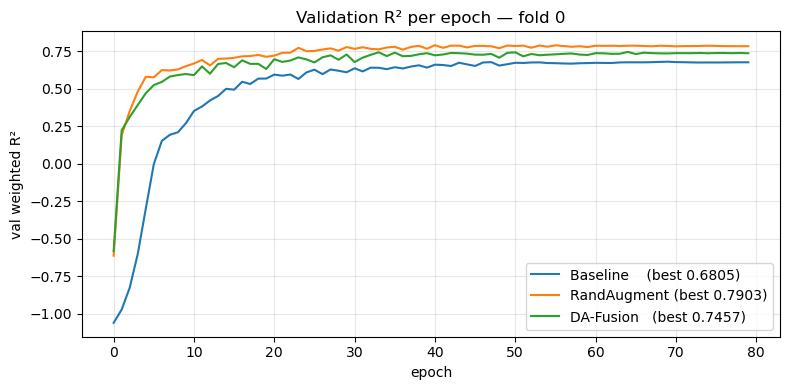

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(hist_1["val_r2"], label=f"Baseline    (best {r2_1:.4f})")
plt.plot(hist_2["val_r2"], label=f"RandAugment (best {r2_2:.4f})")
if hist_3 is not None:
    plt.plot(hist_3["val_r2"], label=f"DA-Fusion   (best {r2_3:.4f})")
plt.xlabel("epoch"); plt.ylabel("val weighted R²")
plt.title("Validation R² per epoch - fold 0")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
